# Baseline CNN Results

Evaluates the trained UNet precipitation retrieval model on the SatRain Korea test domain. Inputs are ABI (16 channels), GMI (13 channels), and ancillary variables (6 channels).

## Setup

Configure input data path and define the three input streams: GMI (passive microwave), ABI (geostationary infrared), and ancillary surface/environment variables.

In [ ]:
%load_ext autoreload
%autoreload 2
from satrain.input import GMI, Ancillary, Geo
from satrain.target import TargetConfig
import os

os.environ["SATRAIN_DATA_PATH"] = "/explore/nobackup/projects/pix4dcloud/sanumolu/"

target_config = TargetConfig()
inputs = [
    # PMW Data (13 channels)
    GMI(normalize="minmax", nan=-1.5, include_angles=False),
    
    # Standard ABI Data (16 channels, single timestep)
    Geo(normalize="minmax", nan=-1.5),
    
    # Ancillary Data (6 variables)
    Ancillary(
        variables=[
            "ten_meter_wind_u", 
            "ten_meter_wind_v", 
            "two_meter_temperature", 
            "two_meter_dew_point", 
            "surface_type", 
            "elevation"
        ],
        normalize="minmax", 
        nan=-1.5
    )
]

geometry = "on_swath"

## Validation Data

Load the validation split as a `DataLoader`. `stack=True` concatenates all input tensors into a single tensor instead of a dictionary.

In [2]:
from torch.utils.data import DataLoader
from satrain.pytorch.datasets import SatRainSpatial

batch_size = 32
num_workers = 8

validation_data = SatRainSpatial(
    base_sensor="gmi",
    geometry=geometry,
    split="validation",
    subset="xl",
    retrieval_input=inputs,
    target_config=target_config,
    augment=False,
    stack=True,
    download=False,
)
validation_loader = DataLoader(
    validation_data,
    shuffle=False,
    batch_size=batch_size,
    num_workers=num_workers,
    worker_init_fn=validation_data.worker_init_fn,
    pin_memory=True,
)

WARNING  Environment variable SATRAIN_DATA_PATH

## Model Architecture

`ResNetBlock` is the basic building block: two 3×3 convolutions with BatchNorm + ReLU and a residual skip connection. `UNet` stacks these into an encoder–decoder with skip connections at each scale, producing three output heads: `surface_precip` (MSE), `probability_of_precip`, and `probability_of_heavy_precip` (both BCE). `IPWGUNet` wraps the UNet in a PyTorch Lightning module with Adam + cosine-annealing LR.

## Load Checkpoint

Load the best saved checkpoint (epoch 69, val_loss = 0.5049) and set the model to eval mode.

In [ ]:
from satrain.input import calculate_input_features
from model import IPWGUNet

checkpoint_path = "/explore/nobackup/projects/pix4dcloud/sanumolu/satrain_ml/baseline_model/checkpoints/baseline_cnn_v5-epoch=162-val_loss=0.4843.ckpt"
input_features = calculate_input_features(inputs)
unet = IPWGUNet.load_from_checkpoint(
    checkpoint_path,
    input_features=input_features,
    internal_features=[32, 64, 128, 256, 512]
)

unet.eval()
print("Model successfully loaded!")

## Validation Sample Plots

Run a single forward pass on the first batch and display retrieved vs. reference precipitation for 32 samples. Missing-data pixels (all inputs below −1.0) are masked out.

In [4]:
# Retrieve first batch from validation loader
import torch
batch = next(iter(validation_loader))
x, y = batch

x = x.to(device="cpu", dtype=torch.float32)
unet = unet.to(device="cpu", dtype=torch.float32)

# Run inference and extract surface precipitation estimates.
with torch.no_grad():
    pred = unet(x)
    surface_precip = pred["surface_precip"]
surface_precip_ref = y["surface_precip"]

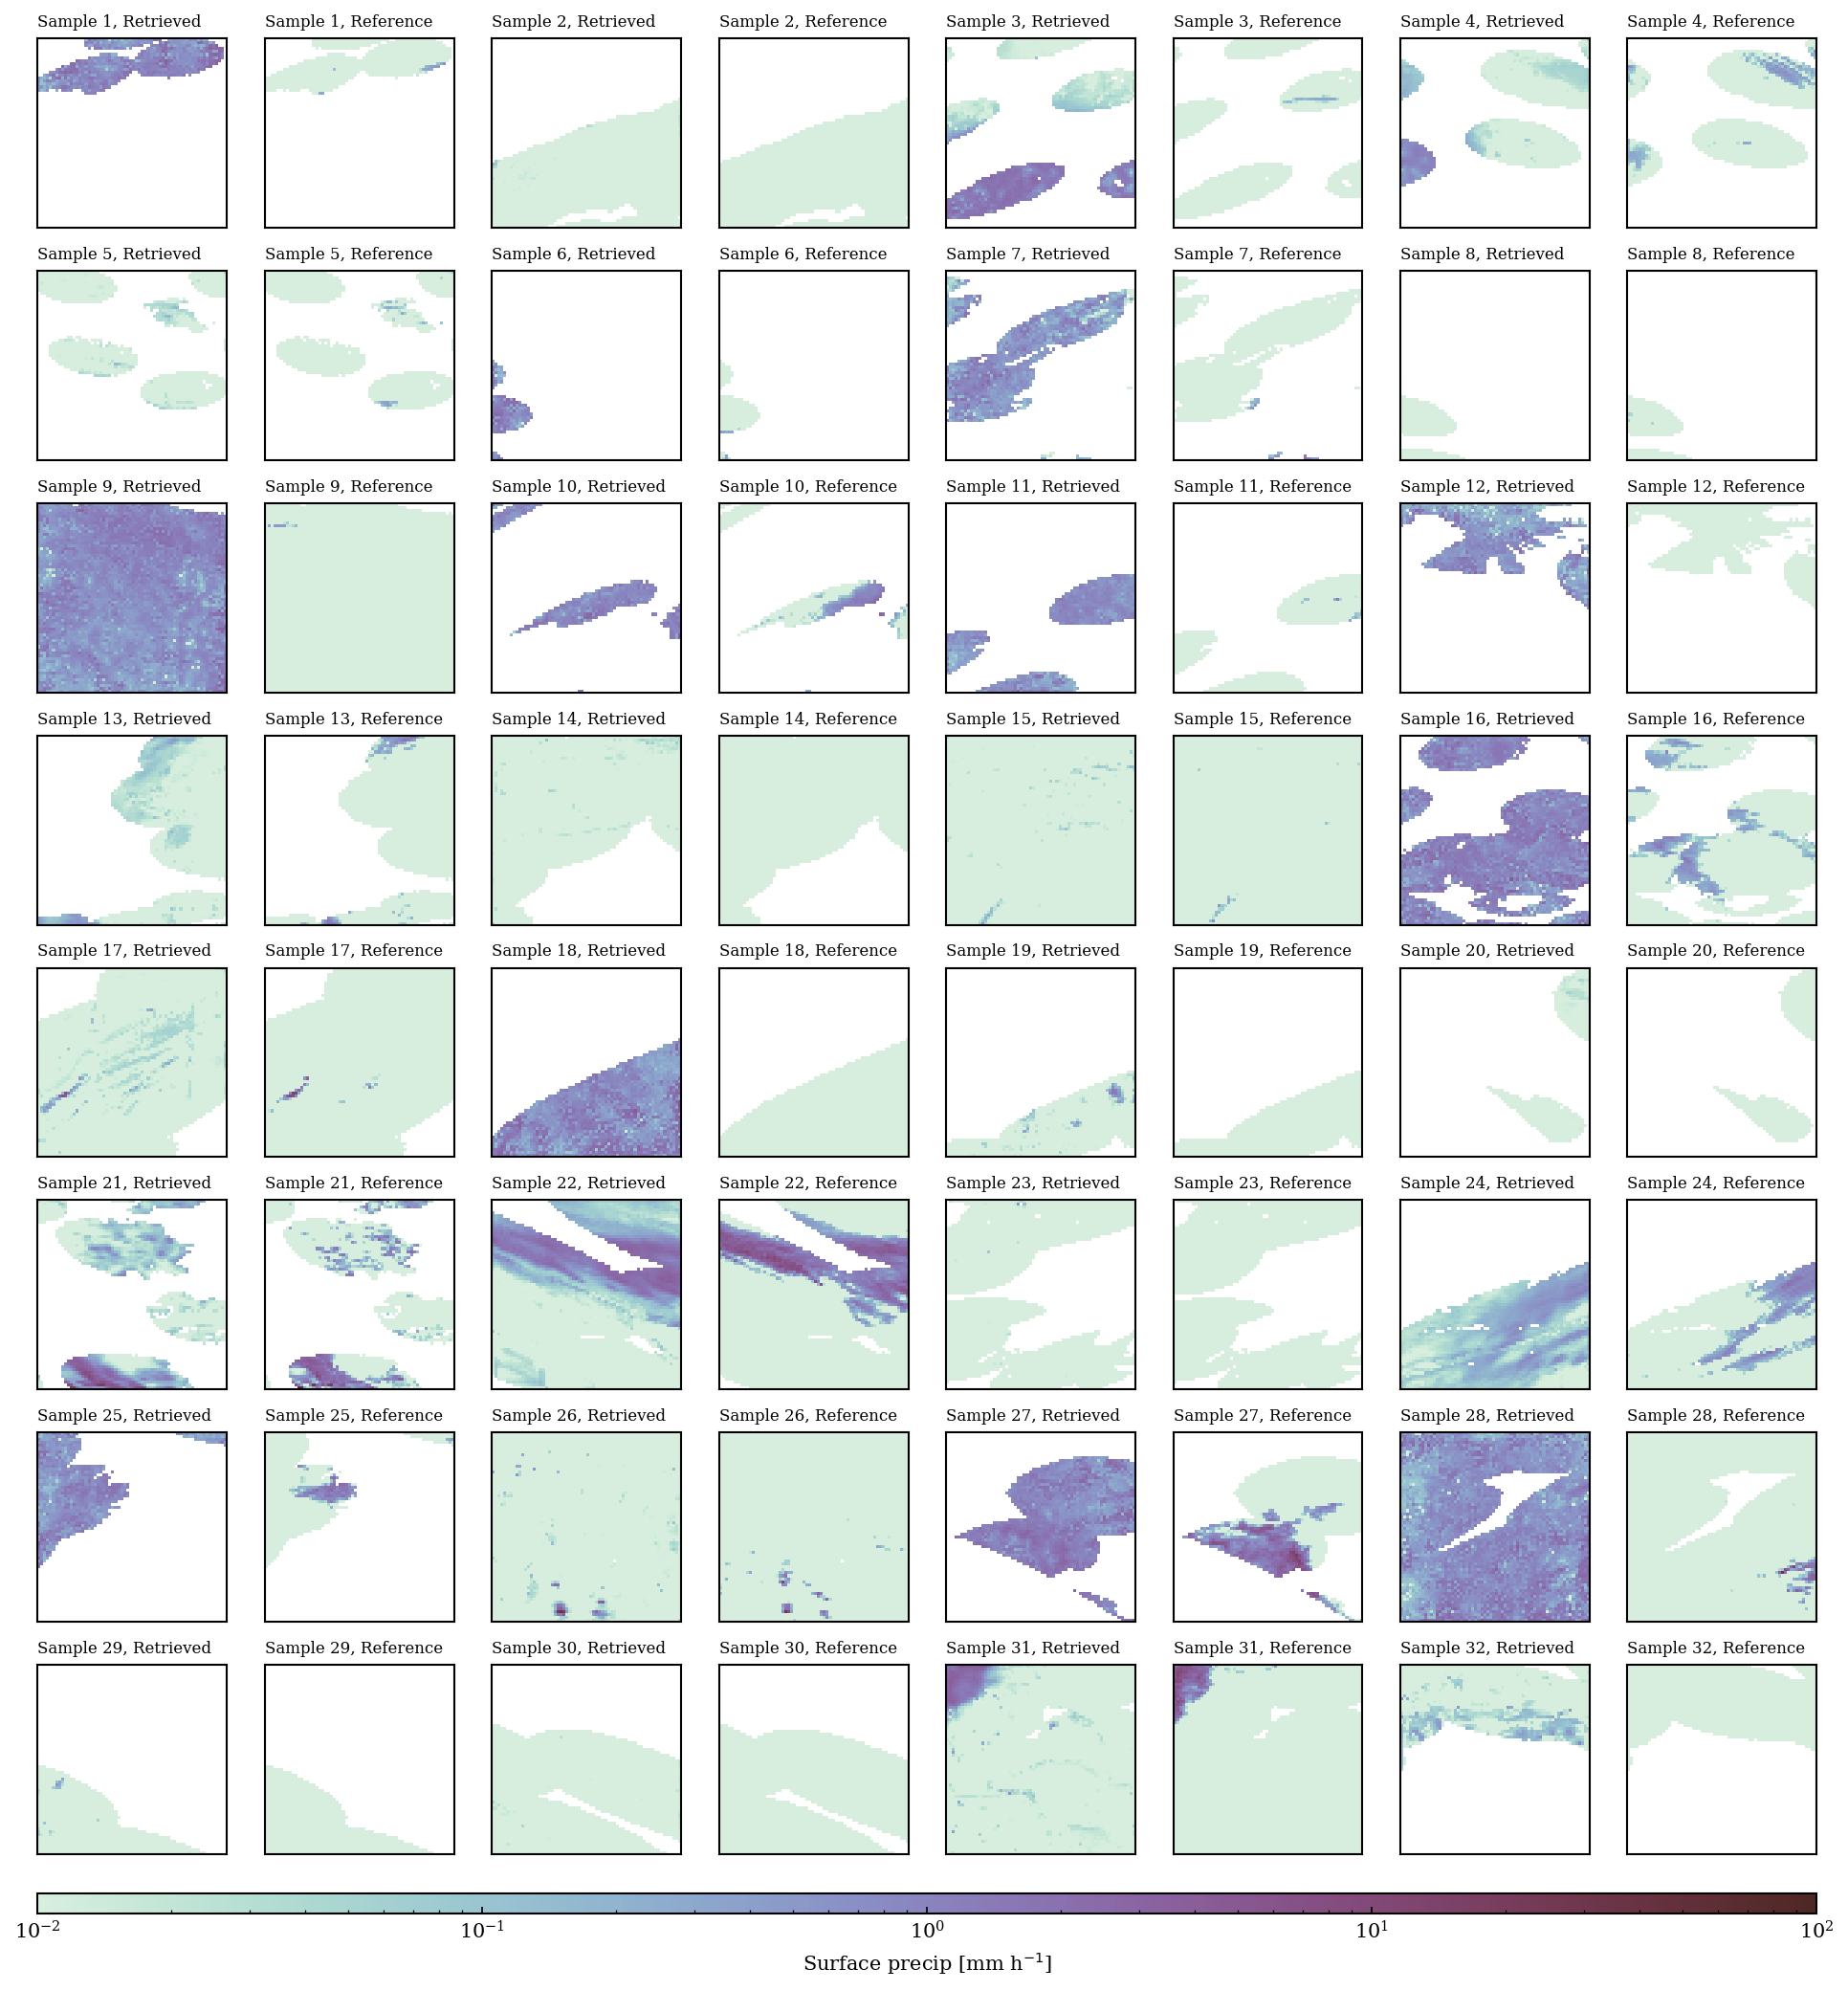

In [12]:
from satrain.plotting import set_style, cmap_precip
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
import numpy as np
import torch

set_style()
fig = plt.figure(figsize=(16, 17))
gs = GridSpec(9, 8, height_ratios = [1.0] * 8 + [0.1])

for row_ind in range(8):
    for col_ind in range(0, 8, 2):

        norm = LogNorm(1e-2, 1e2)
        sample_index = row_ind * 4 + col_ind // 2

        # Mask identifying missing values.
        ref_data = surface_precip_ref[sample_index]
        if torch.is_tensor(ref_data):
            ref_data = ref_data.cpu().numpy()
        mask = np.isnan(ref_data)
        
        ax = fig.add_subplot(gs[row_ind, col_ind])
        precip = np.maximum(surface_precip[sample_index, 0].numpy().copy(), 1e-3)
        precip[mask] = np.nan
        ax.imshow(precip, norm=norm, cmap=cmap_precip)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Sample {sample_index + 1}, Retrieved", fontsize=8)
        
        ax = fig.add_subplot(gs[row_ind, col_ind + 1])
        mappable = ax.imshow(np.maximum(ref_data, 1e-3), norm=norm, cmap=cmap_precip)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"Sample {sample_index + 1}, Reference", fontsize=8)

cax = fig.add_subplot(gs[-1, :])
plt.colorbar(mappable, label="Surface precip [mm h$^{-1}$]", cax=cax, orientation="horizontal")

## Evaluation Setup

Wrap the model in `PytorchRetrieval` and instantiate the `Evaluator` for the Korea test domain. The evaluator tiles full scenes into 64×64 patches (overlap 16) and accumulates predictions for metric computation.

In [5]:
from satrain.pytorch import PytorchRetrieval

import torch
from torch import nn

class Log1pInverter(nn.Module):
    """Wraps the trained model so surface_precip is returned in mm/h
    (inverts the log1p used during training). Detection heads are unchanged."""
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        out = self.model(x)
        out = dict(out)  # copy
        out["surface_precip"] = torch.expm1(out["surface_precip"].clamp(min=0))
        return out


torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running inference on: {torch_device}")
# unet_mmh = Log1pInverter(unet).to(torch_device).eval()

unet_retrieval = PytorchRetrieval(
    unet,
    #unet_mmh,
    retrieval_input=inputs,
    stack=True,
    device=torch_device,
    dtype=torch.float32
)

Running inference on: cuda


In [9]:
from satrain.evaluation import Evaluator
evaluator = Evaluator(
    base_sensor="gmi",
    domain="conus",
    geometry=geometry,
    retrieval_input=inputs,
    download=False
)

WARNING  Environment variable SATRAIN_DATA_PATH

## Case Study

Visual sanity check for a single test scene. The retrieval only produces reliable estimates within the GMI swath; outside the swath, results should be ignored.

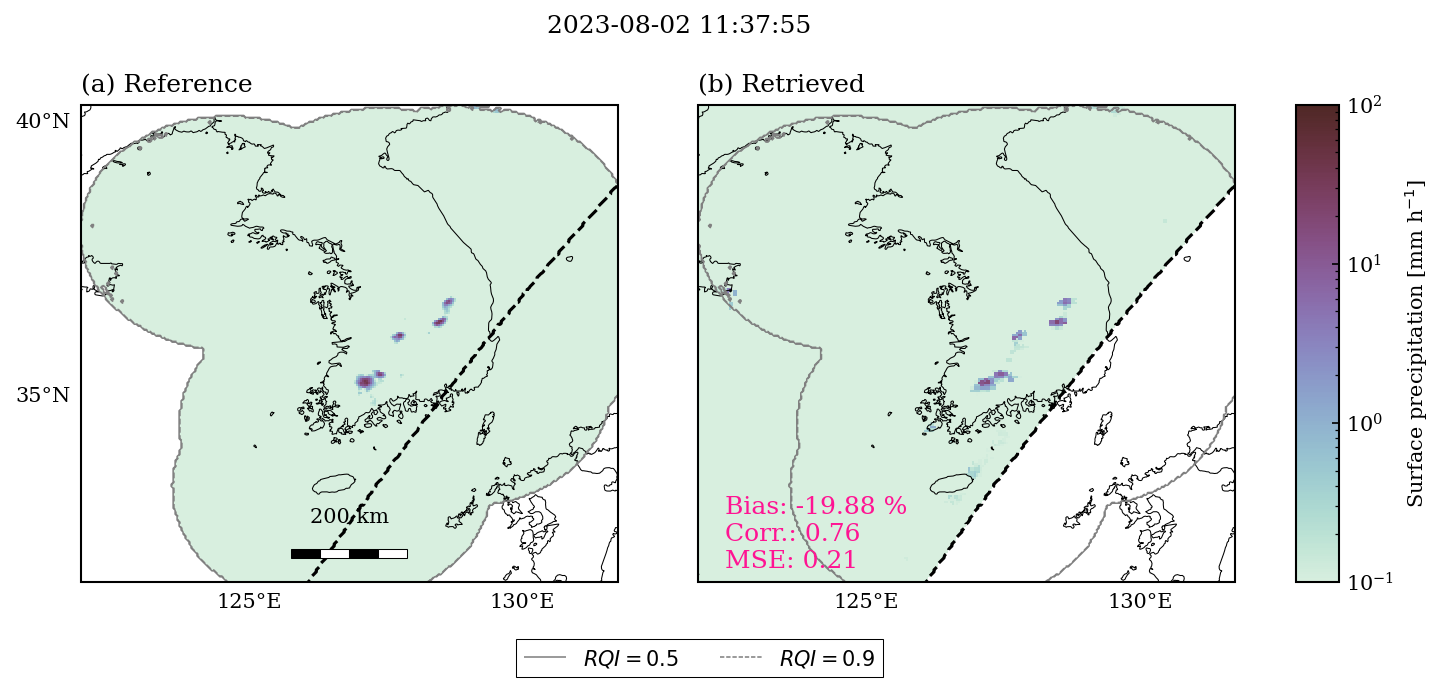

In [15]:
fig = evaluator.plot_retrieval_results(
    501,
    unet_retrieval,
    input_data_format="spatial",
    tile_size=64,
    batch_size=16,
    swath_boundaries=True,
    include_metrics=True
)

## Run Evaluation

Runs the full test-set evaluation. Takes a few minutes. Results are accumulated inside the `evaluator` object and accessed via `get_*_results()` below.

In [10]:
print("Starting evaluation... this may take a few minutes.")
evaluator.evaluate(
    retrieval_fn=unet_retrieval,
    input_data_format="spatial",
    batch_size=32,
    tile_size=64,
    overlap=16,
    output_path="/explore/nobackup/people/sanumolu/satrain_torch/eval_out/baseline",  # <-- ADD THIS
)
print("Evaluation complete.")


Output()

Evaluation complete.


## Results

Metric tables comparing UNet (GMI) against baseline algorithms across quantification, detection, and probabilistic detection tasks. Followed by a clean printed summary.

### Precipitation estimation

In [ ]:
evaluator.get_precip_quantification_results(name="UNet (GMI)").T

,UNet (GMI),ERA5,GPROF V07 (GMI),GPROF V08 (GMI),PERSIANN CCS,PERSIANN PDIR-Now,PU-Net,GPROF-IR
Bias [$\%$],-27.354490,-12.595459,-15.787451,-13.828920,-31.790741,-21.130333,-6.975220,-19.671424
MAE [$mm h^{-1}$],0.131678,0.212852,0.146489,0.128760,0.242497,0.247181,0.208386,0.177095
MSE [$(mm h^{-1})^2$],1.513369,2.469398,1.634189,1.377385,3.129146,2.917237,2.523134,2.095176
SMAPE$_{0.1}$ [$\%$],79.399633,105.729052,89.841430,83.870565,174.468526,158.385099,124.117068,87.593655
Correlation coeff. [],0.712267,0.335582,0.664107,0.725744,0.194232,0.257086,0.410891,0.562775
Effective resolution [$^\circ$],0.237278,inf,0.255166,0.172627,inf,inf,inf,1.091293
Kullback-Leibler Divergence [$None$],0.019479,0.007644,0.019189,0.005499,0.015311,0.001974,0.000881,0.035092


### Precipitation detection

In [ ]:
evaluator.get_precip_detection_results(name="UNet(ABI)").T

NameError: name 'evaluator' is not defined

### Probabilistic precipitation detection

In [ ]:
evaluator.get_prob_precip_detection_results(name="UNet (GMI)").T

,UNet (GMI),ERA5,GPROF V07 (GMI),GPROF V08 (GMI),PERSIANN CCS,PERSIANN PDIR-Now,PU-Net,GPROF-IR
AUC [],0.711317,NaN,0.411177,0.0,NaN,0.0,NaN,0.606846


### Heavy precipitation detection

In [ ]:
evaluator.get_heavy_precip_detection_results(name="UNet (GMI)").T

,UNet (GMI),ERA5,GPROF V07 (GMI),GPROF V08 (GMI),PERSIANN CCS,PERSIANN PDIR-Now,PU-Net,GPROF-IR
POD [],0.148685,0.767467,0.772058,0.0,0.252253,0.370663,0.634386,0.657766
FAR [],0.254849,0.620526,0.571058,NaN,0.607171,0.658323,0.519121,0.368251
HSS [],0.744968,0.274096,0.344245,NaN,0.360400,0.282276,0.423919,0.599131


### Probabilistic heavy precipitation detection

In [ ]:
evaluator.get_prob_heavy_precip_detection_results(name="UNet (GMI)").T

,UNet (GMI),ERA5,GPROF V07 (GMI),GPROF V08 (GMI),PERSIANN CCS,PERSIANN PDIR-Now,PU-Net,GPROF-IR
AUC [],0.217574,NaN,0.47996,NaN,NaN,0.0,NaN,0.291001


### Summary table of compiled model metrics

In [11]:
MODEL_NAME = "UNet Baseline (GMI+ABI)"

quant   = evaluator.get_precip_quantification_results(name=MODEL_NAME).loc[MODEL_NAME]
detect  = evaluator.get_precip_detection_results(name=MODEL_NAME).loc[MODEL_NAME]
prob    = evaluator.get_prob_precip_detection_results(name=MODEL_NAME).loc[MODEL_NAME]
hdetect = evaluator.get_heavy_precip_detection_results(name=MODEL_NAME).loc[MODEL_NAME]
hprob   = evaluator.get_prob_heavy_precip_detection_results(name=MODEL_NAME).loc[MODEL_NAME]

sections = [
    ("Precipitation Quantification",  quant),
    ("Precipitation Detection",        detect),
    ("Prob. Precipitation Detection",  prob),
    ("Heavy Precip. Detection",        hdetect),
    ("Prob. Heavy Precip. Detection",  hprob),
]

WIDTH = 52
print(f"{'=' * WIDTH}")
print(f"  Model: {MODEL_NAME}")
print(f"{'=' * WIDTH}")
for title, series in sections:
    print(f"\n  {title}")
    print(f"  {'-' * (WIDTH - 2)}")
    for metric, value in series.items():
        label = metric.strip()
        if isinstance(value, float):
            print(f"  {label:<42}  {value:>8.4f}")
        else:
            print(f"  {label:<42}  {value!r:>8}")
print(f"\n{'=' * WIDTH}")


  Model: UNet Baseline (GMI+ABI)

  Precipitation Quantification
  --------------------------------------------------
  Bias [$\%$]                                  -5.8932
  MAE [$mm h^{-1}$]                             0.0818
  MSE [$(mm h^{-1})^2$]                         0.5644
  SMAPE$_{0.1}$ [$\%$]                         74.4827
  Correlation coeff. []                         0.7143
  Effective resolution [$^\circ$]               0.1690
  Kullback-Leibler Divergence [$None$]          0.0252

  Precipitation Detection
  --------------------------------------------------
  POD []                                        0.7137
  FAR []                                        0.2551
  HSS []                                        0.7319

  Prob. Precipitation Detection
  --------------------------------------------------
  AUC []                                        0.7222

  Heavy Precip. Detection
  --------------------------------------------------
  POD []                       